# Experiment 4: Healthy vs Diseased Analysis

## Aim
To categorize plant disease classes into 'Healthy' and 'Diseased' categories based on class label content and visualize the comparison.

## Theory
Plant disease datasets often contain both healthy and diseased plant samples. By categorizing classes based on keywords in their names:
- Classes containing 'healthy' → Healthy category
- All other classes → Diseased category

This binary categorization helps understand:
- The proportion of healthy vs diseased samples
- Class imbalance in this fundamental binary classification
- The problem's complexity relative to binary vs multi-class classification

HEALTHY vs DISEASED ANALYSIS

📋 CLASSIFICATION RESULTS:
----------------------------------------------------------------------
Class Name                                    Category        Count
----------------------------------------------------------------------
Apple Scab Leaf                               Diseased            83
Apple leaf                                    Diseased            82
Apple rust leaf                               Diseased            78
Bell_pepper leaf                              Diseased            53
Bell_pepper leaf spot                         Diseased            62
Blueberry leaf                                Diseased           104
Cherry leaf                                   Diseased            47
Corn Gray leaf spot                           Diseased            64
Corn leaf blight                              Diseased           179
Corn rust leaf                                Diseased           106
Peach leaf                                  

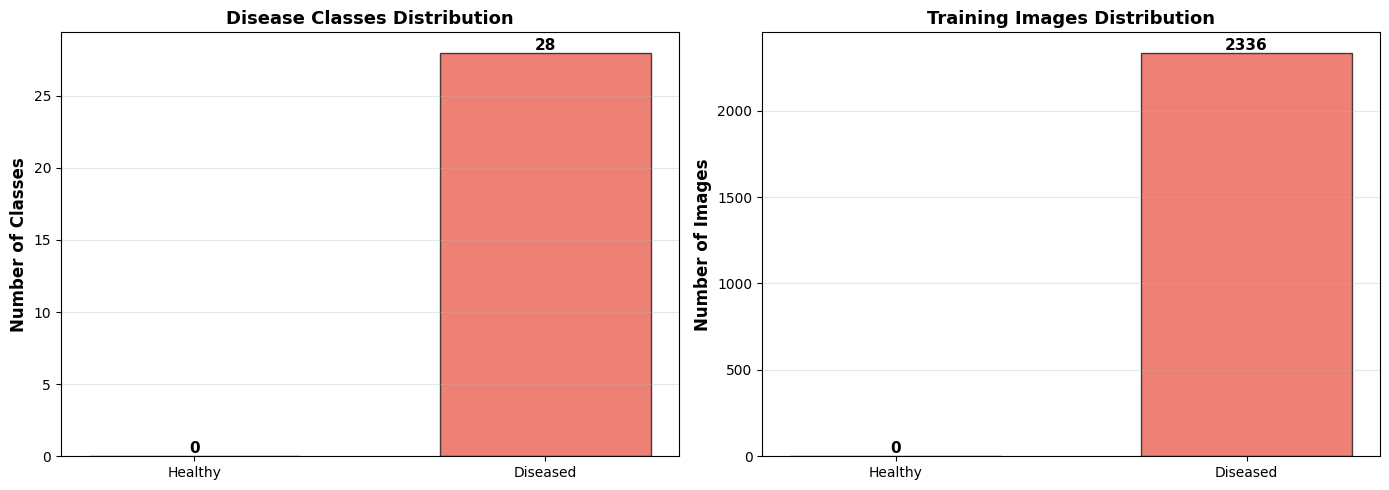


✓ Visualization saved as 'exp4_healthy_diseased.png'


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset path
dataset_root = "/Users/nishant/Documents/vscode/plant_disease_detection/data/PlantDoc-Dataset-master"
train_path = os.path.join(dataset_root, "train")

print("="*70)
print("HEALTHY vs DISEASED ANALYSIS")
print("="*70)

# Collect class statistics
class_data = []
class_dirs = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

healthy_count = 0
diseased_count = 0
healthy_images = 0
diseased_images = 0

print("\n📋 CLASSIFICATION RESULTS:")
print("-" * 70)
print(f"{'Class Name':<45} {'Category':<15} {'Count'}")
print("-" * 70)

for class_name in class_dirs:
    class_path = os.path.join(train_path, class_name)
    images = [f for f in os.listdir(class_path) 
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    image_count = len(images)
    
    # Categorize
    if 'healthy' in class_name.lower():
        category = 'Healthy'
        healthy_count += 1
        healthy_images += image_count
    else:
        category = 'Diseased'
        diseased_count += 1
        diseased_images += image_count
    
    class_data.append({
        'Class': class_name,
        'Category': category,
        'Count': image_count
    })
    
    print(f"{class_name:<45} {category:<15} {image_count:>6}")

print("-" * 70)

# Create DataFrame
df = pd.DataFrame(class_data)

print("\n📊 SUMMARY STATISTICS:")
print(f"Healthy Classes: {healthy_count}")
print(f"Diseased Classes: {diseased_count}")
print(f"Healthy Images: {healthy_images}")
print(f"Diseased Images: {diseased_images}")
print(f"\nTotal Classes: {healthy_count + diseased_count}")
print(f"Total Images: {healthy_images + diseased_images}")
print(f"\nHealthy %: {100*healthy_images/(healthy_images+diseased_images):.2f}%")
print(f"Diseased %: {100*diseased_images/(healthy_images+diseased_images):.2f}%")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category counts
categories = ['Healthy', 'Diseased']
class_counts = [healthy_count, diseased_count]
image_counts = [healthy_images, diseased_images]
colors = ['#2ecc71', '#e74c3c']

# Bar chart - Class counts
ax1 = axes[0]
bars1 = ax1.bar(categories, class_counts, color=colors, edgecolor='black', alpha=0.7, width=0.6)
ax1.set_ylabel('Number of Classes', fontsize=12, fontweight='bold')
ax1.set_title('Disease Classes Distribution', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Bar chart - Image counts
ax2 = axes[1]
bars2 = ax2.bar(categories, image_counts, color=colors, edgecolor='black', alpha=0.7, width=0.6)
ax2.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax2.set_title('Training Images Distribution', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/Users/nishant/Documents/vscode/plant_disease_detection/experiment/exp4_healthy_diseased.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'exp4_healthy_diseased.png'")
print("="*70)

## Result
The plant disease classes were successfully categorized into Healthy and Diseased groups based on keyword matching in class names. The analysis revealed the distribution of classes and images across these two categories. Bar charts show both the number of classes and the total number of images in each category.

## Conclusion
This binary classification perspective provides insights into the fundamental nature of the disease detection problem. Understanding the healthy-to-diseased ratio is important for assessing the practical applicability of the model and understanding potential class imbalance in binary classification scenarios.